# Exercise 02: Image classification with a CNN

## Goal

You will create and train a convolutional neural network to classify MRI scans of the brain. One class contains scans with a brain tumor and the other scans without tumor. The images are availabe in two folders. The folder ```yes``` contains the images with a tumor and the folder ```no``` those without tumor.

What you will learn in the exercise:

* how to prepare the data
  * split into train and validation data
  * use data augmentation
  * normalize the data
* Create and train a convolutional neural network
* Compute metrics to evaluate the model

## Download data

Install the dload package, that allows to download and unzip a zip-archive.

In [1]:
!pip install git+https://github.com/regtm/dload.git

  Cloning https://github.com/regtm/dload.git to /tmp/pip-req-build-icsc8vx3
  Running command git clone --filter=blob:none --quiet https://github.com/regtm/dload.git /tmp/pip-req-build-icsc8vx3
  Resolved https://github.com/regtm/dload.git to commit dcf45f89e00aa1de6280657327e8a26e299fcb67
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dload: filename=dload-0.6-py3-none-any.whl size=7334 sha256=a8ad6505c5481eedabe24de558f51e81026f345926ee748aec274a7025901e03
  Stored in directory: /tmp/pip-ephem-wheel-cache-dlfw73i7/wheels/c1/06/47/5b379cb4f66ad12efa4589a0809345c6ca45cb6ed5ca2b6488
Successfully built dload


Download and unzip the data for the exercise. Change the path ``/content/`` to the path on your machine, where you want to save the data.

In [4]:
import dload
__file__ = "."
url = 'https://github.com/MontpellierRessourcesImagerie/mri-workshop-machine-learning/releases/download/v2025-pre/data.zip'
dload.save_unzip(url, "/home/baecker/content/")

'/home/baecker/content/'

## Exercise

Write the code in the empty cells below, following the instructions and execute them. The cells that are already filled in, you just have to execute them (shift + enter).


The next cell switches off warnings, so that we do not get distracted by them.

In [5]:
import warnings
warnings.filterwarnings('ignore')

We import the python modules we will use in the exercise.

* **tensorflow:** Create and use ANNs.
* **numpy:** Vector and matrix calculations
* **classification_report:** Report metrics to evaluate the model
* **confusion_matrix:** Calculate a confusion matrix to evaluate the model
* **pyplot:** Create plots
* **Counter** We will use the counter to calculate the ratio between the sizes of the two classes, positive and negative.

In [6]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from collections import Counter
print(tf.keras.__version__)

I0000 00:00:1780931285.394794   73304 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780931285.395288   73304 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780931285.428553   73304 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


3.14.1


I0000 00:00:1780931286.288192   73304 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780931286.288425   73304 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Exercise 2.1

We create a training dataset and a validation dataset from the images in the folders. The path must point to the top-folder, containing the subfolders with instances of the different classes.

Set the missing values for the parameters in the cell below.

* Set the path to the input directory, the directory which contains the ```yes``` and ```no``` folders.
* Let the function infer the labels from the subfolders
* Use the binary label mode for usage with the binary-cross-entropy loss-function
* Resize the images in x and y so that all images will have the same size
* Set the batch_size, using a variable, since we will need it later again

In [8]:
import os
from keras.utils import image_dataset_from_directory

BATCH_SIZE = 32
path = '/home/baecker/content/data/train/'
training_dataset, validation_dataset = image_dataset_from_directory(
    path,
    color_mode='grayscale',
    labels='inferred',
    label_mode='binary',
    batch_size=BATCH_SIZE,
    image_size=(256, 256),
    pad_to_aspect_ratio=True,
    shuffle=True,
    seed=1234,
    validation_split=0.15,
    subset = 'both'
    )

Found 216 files belonging to 2 classes.
Using 184 files for training.
Using 32 files for validation.


The ``image_dataset_from_directory``-function returns a [tf.data.Dataset](https://www.tensorflow.org/api_docs/python/tf/data/Dataset) object. The Dataset contains the pairs of images and labels for each batch.

In [9]:
ds = training_dataset.take(1).get_single_element()
print(ds[0].shape)
print(tf.transpose(ds[1]))

(32, 256, 256, 1)
tf.Tensor(
[[1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0.
  1. 0. 0. 1. 1. 0. 1. 1.]], shape=(1, 32), dtype=float32)


We display two pairs of ground truth and data.

[0.]


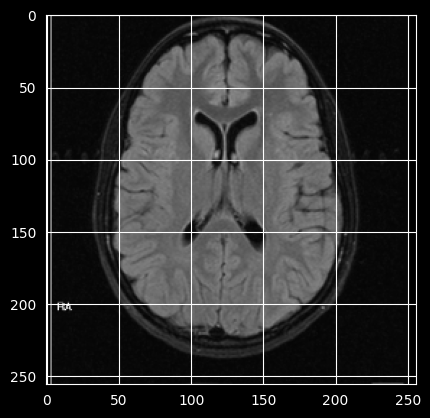

[1.]


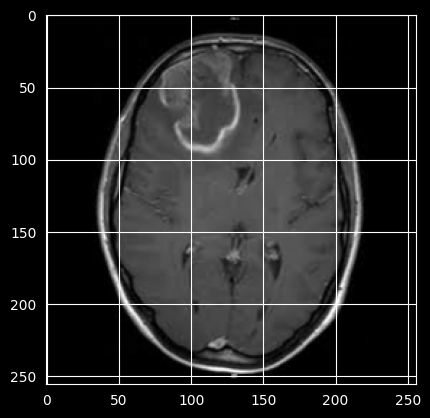

In [10]:
ds1 = training_dataset.take(1).get_single_element()
print(ds1[1][0].numpy())
plt.imshow(ds1[0][0], cmap='gray')
plt.show()
ds2 = training_dataset.take(1).get_single_element()
print(ds2[1][0].numpy())
plt.imshow(ds2[0][0], cmap='gray')
plt.show()

### Exercise 2.2

Apply data augmentation to the training dataset. Add horizontal random flips and random scaling to the images.

In [11]:
data_augmentation = tf.keras.models.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomZoom(0.2)
    ])
training_dataset = training_dataset.map(lambda x, y: (data_augmentation(x), y))

[0.]


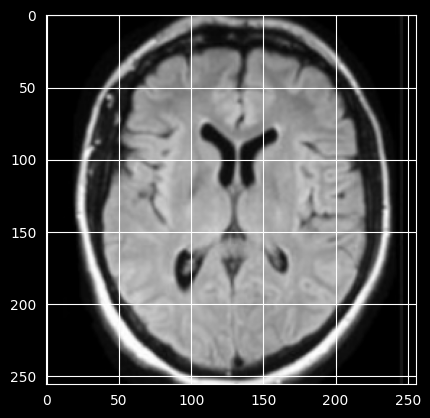

[1.]


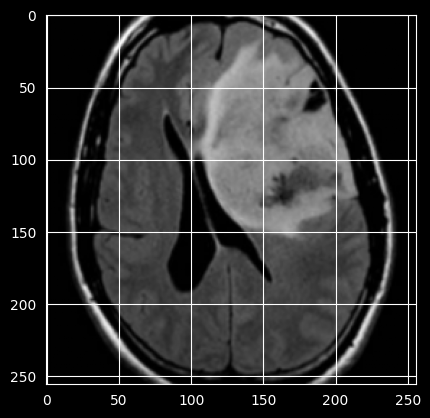

In [13]:
ds1 = training_dataset.take(1).get_single_element()
print(ds1[1][0].numpy())
plt.imshow(ds1[0][0], cmap='gray')
plt.show()
ds2 = training_dataset.take(1).get_single_element()
print(ds2[1][0].numpy())
plt.imshow(ds2[0][0], cmap='gray')
plt.show()

### Exercise 2.3

Create a CNN consisting of a convolutional part followed by a Flatten layer and a fully connected part. Display the summary of the model at the end using ``model.summary()``. The summary can help you to check if the aritechture is resonable. Check the sizes of the feature maps and the number of parameters in the fully connected part. Do not make the model too big, too many parameters can lead to overfitting.

Here are some of the layer types you might want to use:
    
    - tf.keras.layers.Rescaling(factor, input_shape=(image_height, image_width, nr_of_channels))
      - You need to set the input_shape only for the first layer
    - tf.keras.layers.Conv2D(nr_of_convolutions,
                             (filter_size_x, filter_size_y),
                             padding=padding_mode,
                             activation=activation_function)
    - tf.keras.layers.AveragePooling2D(height, width)
    - tf.keras.layers.MaxPooling2D(height, width)
    - tf.keras.layers.Flatten()
    - tf.keras.layers.Dense(number_of_units, activation=activation_function)  
    - tf.keras.layers.Dropout(rate)
    - The output unit is just another dense layer with an appropriate activation function

The model is created by passing a list of layers to ``tf.keras.models.Sequential(list_of_layers)``. Assign the result to the variable ```model```. If necessary consult the keras documentation to find out about the parameters you can use with each type of layer.

In [14]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(256, 256, 1)),
    tf.keras.layers.Conv2D(32, (5, 5), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.AveragePooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')])
# tf.keras.utils.plot_model(model, show_shapes=True)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 128, 128, 32)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 262144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    33,554,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,579,073 (128.09 MB)

 Trainable params: 33,578,561 (128.09 MB)

 Non-trainable params: 512 (2.00 KB)

### Exercise 2.4

Set the optimizer, the loss function and at least one additional metric, for example accuracy, by calling the method ``model.compile(optimizer=optimizer, loss=loss_function, metrics=list_of_metrics)``.

To create for example the adam optimizer use ``tf.keras.optimizers.Adam(learning_rate=0.001)``.

In [15]:
additional_metric = 'accuracy'
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = 'crossentropy',
    metrics=[additional_metric])

We calculate the ratio between the number of elements in the two classes. It will be used to adjust the calculation of the loss and the metrics to the imbalance.

In [16]:
labels = list(os.walk(path))
labels = ['no' for l in labels[1][2]] + ["yes" for l in labels[2][2]]
counter = Counter(labels)
max_val = float(max(counter.values()))
class_weights = {index : max_val/num_images for index, (class_id, num_images) in enumerate(counter.items())}
print(class_weights)

{0: 1.6024096385542168, 1: 1.0}


### Exercise 2.5

Train the network by calling ``model.fit(...)``. The method returns the history of the loss, of the validation loss (val_loss) and of the additional metrics. Set the number of epochs.

In [17]:
history = model.fit(
    training_dataset,
    class_weight=class_weights,
    validation_data = validation_dataset,
    epochs=80,
    verbose=1,
    )

Epoch 1/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 912ms/step - accuracy: 0.4783 - loss: 1.3737 - val_accuracy: 0.5938 - val_loss: 0.6293
Epoch 2/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 889ms/step - accuracy: 0.5435 - loss: 1.1747 - val_accuracy: 0.5938 - val_loss: 0.6658
Epoch 3/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 887ms/step - accuracy: 0.5598 - loss: 1.0339 - val_accuracy: 0.5312 - val_loss: 0.6760
Epoch 4/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 881ms/step - accuracy: 0.6196 - loss: 0.9531 - val_accuracy: 0.5000 - val_loss: 0.6959
Epoch 5/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 874ms/step - accuracy: 0.6250 - loss: 0.7909 - val_accuracy: 0.5000 - val_loss: 0.6842
Epoch 6/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 887ms/step - accuracy: 0.5761 - loss: 0.9622 - val_accuracy: 0.5000 - val_loss: 0.7037
Epoch 7/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 881ms/step - accuracy: 0.6033 - loss: 1.0483 - val_accuracy: 0.4375 - val_loss: 0.7776
Epoch 8/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 869ms/step - accuracy: 0.5761 - loss: 0.9022 - val_accuracy: 0.4375 - val_loss:

### Exercise 2.6

We plot the history of the loss and the validation loss. If the loss is getting smaller over time the model is learning. If the validation loss does not evolve similar to the loss, it means that the model is not generalizing, i.e. overfitting.

Is the model learning? Does it show signs of overfitting?

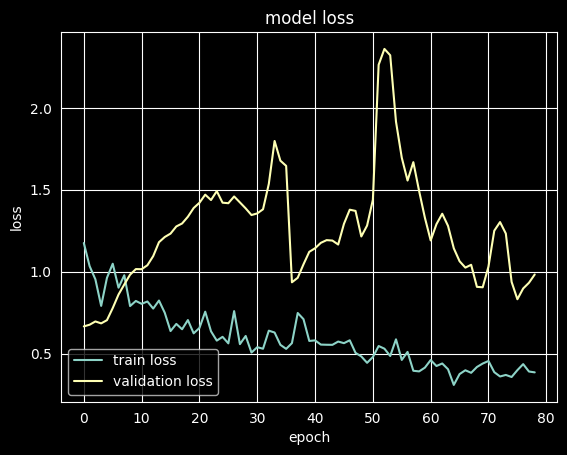

In [18]:
plt.plot(history.history['loss'][1:])
plt.plot(history.history['val_loss'][1:])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train loss', 'validation loss'], loc='lower left')
plt.show()

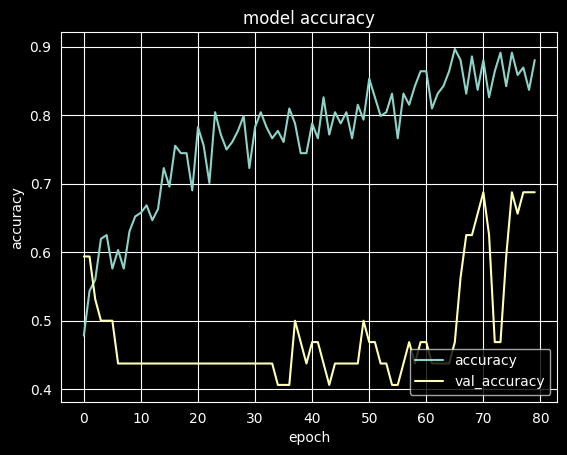

In [19]:
plt.plot(history.history[additional_metric])
plt.plot(history.history['val_' + additional_metric])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['accuracy', "val_accuracy"], loc='lower right')
plt.show()

In [20]:
model.evaluate(validation_dataset, verbose=2)

1/1 - 0s - 198ms/step - accuracy: 0.6875 - loss: 0.9827


[0.9827417731285095, 0.6875]

### Exercise 2.7

We will evaluate the model on the test dataset.

Load the test dataset, the same way you loaded the training dataset before.

In [22]:
BATCH_SIZE = 37
test_path = '/home/baecker/content/data/test/'
test_dataset = image_dataset_from_directory(
    test_path,
    color_mode='grayscale',
    labels='inferred',
    label_mode='binary',
    batch_size=BATCH_SIZE,
    image_size=(256, 256),
    pad_to_aspect_ratio=True,
    shuffle=False,
    )

Found 37 files belonging to 2 classes.


In [23]:
model.evaluate(test_dataset, verbose=2)

1/1 - 0s - 202ms/step - accuracy: 0.9189 - loss: 0.3181


[0.31811895966529846, 0.9189189076423645]

We calculate the confusion matrix and display a report of different metrics.

In [24]:
gt = [label.numpy()[0].item()  for label in list(test_dataset)[0][1]]
Y_pred = model.predict(test_dataset)
y_pred = np.rint(Y_pred)
print('Confusion Matrix')
print(confusion_matrix(gt, y_pred))
print('Classification Report')
print(classification_report(gt, y_pred, target_names=['no', 'yes']))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
Confusion Matrix
[[13  2]
 [ 1 21]]
Classification Report
              precision    recall  f1-score   support

          no       0.93      0.87      0.90        15
         yes       0.91      0.95      0.93        22

    accuracy                           0.92        37
   macro avg       0.92      0.91      0.91        37
weighted avg       0.92      0.92      0.92        37

